<a href="https://colab.research.google.com/github/vikramshrivastav734-prog/AQI-Prediction-Project/blob/main/04_Sales_Forecasting/Time_Series_Sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Generating localized Time-Series Sales dataset...
Dataset generated successfully! Previewing historical sales entries:
   Day   Sales ($)
0    1  218.401425
1    2  202.852071
2    3  229.930656
3    4  259.690896
4    5  210.475399

Forecasting complete! Sample projections for upcoming weeks:
Day 101: Projected Sales -> $552.50
Day 102: Projected Sales -> $556.04
Day 103: Projected Sales -> $559.58
Day 104: Projected Sales -> $563.12
Day 105: Projected Sales -> $566.66


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(



Saved forecasting visualization as 'sales_forecast_trend.png'


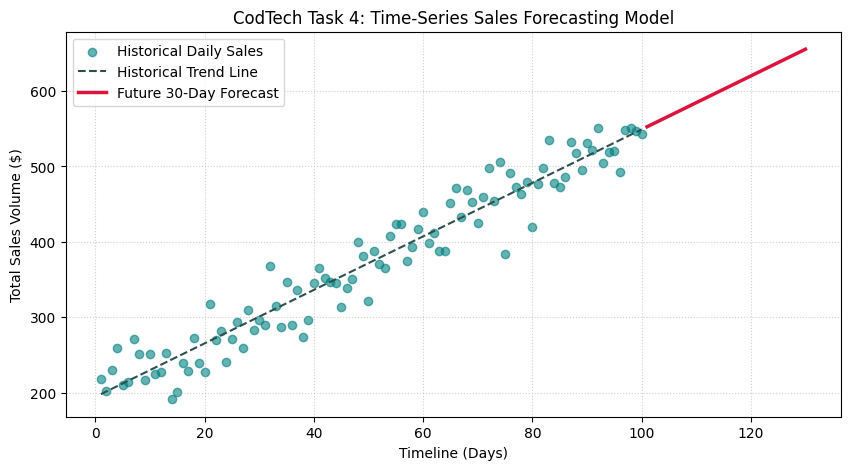

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

print("Generating localized Time-Series Sales dataset...")

# 1. Create historical daily sales data for a retail store (100 days)
np.random.seed(42)
days = np.arange(1, 101).reshape(-1, 1)
# Create a steady upward trend in sales with some realistic daily randomness
sales = 200 + (3.5 * days.flatten()) + np.random.normal(0, 30, 100)

df = pd.DataFrame({'Day': days.flatten(), 'Sales ($)': sales})
print("Dataset generated successfully! Previewing historical sales entries:")
print(df.head())

# 2. Train the Time-Series Trend Model (Linear Regression)
X = df[['Day']]
y = df['Sales ($)']

model = LinearRegression()
model.fit(X, y)

# 3. Forecast future sales for the next 30 days
future_days = np.arange(101, 131).reshape(-1, 1)
predicted_sales = model.predict(future_days)

print("\nForecasting complete! Sample projections for upcoming weeks:")
for d, s in zip(future_days.flatten()[:5], predicted_sales[:5]):
    print(f"Day {d}: Projected Sales -> ${s:.2f}")

# 4. Generate the Time-Series Forecast Plot
plt.figure(figsize=(10, 5))
# Plot past data points
plt.scatter(df['Day'], df['Sales ($)'], color='teal', alpha=0.6, label='Historical Daily Sales')
# Plot the trend line tracking historical sales
plt.plot(df['Day'], model.predict(X), color='darkslategrey', linestyle='--', label='Historical Trend Line')
# Plot future predicted points extending forward
plt.plot(future_days, predicted_sales, color='crimson', linewidth=2.5, label='Future 30-Day Forecast')

plt.title('CodTech Task 4: Time-Series Sales Forecasting Model')
plt.xlabel('Timeline (Days)')
plt.ylabel('Total Sales Volume ($)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.savefig('sales_forecast_trend.png')
print("\nSaved forecasting visualization as 'sales_forecast_trend.png'")
plt.show()